In [1]:
pip install lightgbm 

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
from lightgbm import LGBMClassifier 
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_validate
from sklearn.metrics import roc_auc_score
from sklearn.metrics import average_precision_score
from sklearn.metrics import precision_recall_curve
import shap
import matplotlib.pyplot as plt


In [3]:
from data.features import build_flat_feature_table, get_feature_cols

In [4]:
df = build_flat_feature_table()

In [5]:
df

,SK_ID_CURR,TARGET,AMT_CREDIT,AMT_ANNUITY,AMT_INCOME_TOTAL,AMT_GOODS_PRICE,credit_income_ratio,annuity_income_ratio,credit_goods_ratio,age_years,...,bureau_total_credit,bureau_total_debt,bureau_overdue_count,prev_app_count,prev_approved,prev_refused,prev_approval_rate,install_count,install_late_count,install_avg_delay_days
0,100002,1,406597.5,24700.5,202500.0,351000.0,2.007889,0.121978,1.158397,25.920548,...,865055.565,245781.00,0.0,1.0,1.0,0.0,1.000000,19.0,0.0,20.421053
1,100003,0,1293502.5,35698.5,270000.0,1129500.0,4.790750,0.132217,1.145199,45.931507,...,1017400.500,0.00,0.0,3.0,3.0,0.0,1.000000,25.0,0.0,7.160000
2,100004,0,135000.0,6750.0,67500.0,135000.0,2.000000,0.100000,1.000000,52.180822,...,189037.800,0.00,0.0,1.0,1.0,0.0,1.000000,3.0,0.0,7.666667
3,100006,0,312682.5,29686.5,135000.0,297000.0,2.316167,0.219900,1.052803,52.068493,...,0.000,0.00,0.0,9.0,5.0,1.0,0.555556,16.0,0.0,19.375000
4,100007,0,513000.0,21865.5,121500.0,513000.0,4.222222,0.179963,1.000000,54.608219,...,146250.000,0.00,0.0,6.0,6.0,0.0,1.000000,66.0,16.0,3.636364
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307506,456251,0,254700.0,27558.0,157500.0,225000.0,1.617143,0.174971,1.132000,25.553425,...,0.000,0.00,0.0,1.0,1.0,0.0,1.000000,7.0,0.0,36.285714
307507,456252,0,269550.0,12001.5,72000.0,225000.0,3.743750,0.166687,1.198000,56.917808,...,0.000,0.00,0.0,1.0,1.0,0.0,1.000000,6.0,1.0,2.833333
307508,456253,0,677664.0,29979.0,153000.0,585000.0,4.429176,0.195941,1.158400,41.002740,...,3960000.000,1795833.00,0.0,2.0,2.0,0.0,1.000000,14.0,1.0,14.500000
307509,456254,1,370107.0,20205.0,171000.0,319500.0,2.164368,0.118158,1.158394,32.769863,...,45000.000,0.00,0.0,2.0,2.0,0.0,1.000000,19.0,0.0,19.000000


In [6]:
feature_cols = get_feature_cols(df)

In [7]:
from sklearn.model_selection import train_test_split

In [8]:
X= df[feature_cols]
y = df['TARGET']

X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [9]:
neg, pos = (y_train==0).sum(), (y_train==1).sum()
scale_pos_weight = neg / pos

In [10]:
lgbm = LGBMClassifier(n_estimators=300, max_depth=6, learning_rate=0.05,
            num_leaves=31, subsample=0.8, colsample_bytree=0.8,
            scale_pos_weight=scale_pos_weight, n_jobs=-1,
            random_state=42, verbose=-1,)

In [11]:
cv = cross_validate(lgbm, X_train,y_train, cv=StratifiedKFold(5, shuffle=True, random_state=42), scoring=["roc_auc","average_precision"],)

In [12]:
print(f"CV AUC:{cv['test_roc_auc'].mean():.4f}")
print(f"CV AP: {cv['test_average_precision'].mean():.4f}")

CV AUC:0.7637
CV AP: 0.2505


In [13]:
#model training 
lgbm.fit(X_train,y_train)
calibrated = CalibratedClassifierCV(lgbm, cv=None, method='isotonic')
calibrated.fit(X_test,y_test)

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",LGBMClassifie... verbose=-1)
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'isotonic'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary <n_jobs>` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
Name,Type,Value
"calibrated_classifiers_ calibrated_classifiers_: list (len() equal to cv or 1 if `ensemble=False`)The list of classifier and calibrator pairs.- When `ensemble=True`, `n_cv` fitted `estimator` and calibrator pairs. `n_cv` is the number of cross-validation folds.- When `ensemble=False`, the `estimator`, fitted on all the data, and fitted calibrator... versionchanged:: 0.24 Single calibrated classifier case when `ensemble=False`.",list,"[<sklearn.cali...t 0x179c36e50>, <

In [14]:
y_prob = calibrated.predict_proba(X_test)[:,1]
auc    = roc_auc_score(y_test, y_prob)
ap     = average_precision_score(y_test, y_prob)
gini = 2 * auc - 1
print(f"Holdout AUC: {auc:.4f} | Gini: {gini: .4f} | AP: {ap:.4f}")
prec, recall, thresholds = precision_recall_curve(y_test,y_prob)
f1score = 2*prec*recall/(prec+recall+1e-8)
threshold = float(thresholds[np.argmax(f1score)])
print(f"Optimal threshold: {threshold:.4f}")

Holdout AUC: 0.8979 | Gini:  0.7958 | AP: 0.4633
Optimal threshold: 0.1668


In [15]:
print("Computing SHAP values...")
explainer = shap.TreeExplainer(lgbm)
sample = X_test.sample(500,random_state=42)
shap_values = explainer.shap_values(sample)
if isinstance(shap_values, list):
    shap_values=shap_values[1]

Computing SHAP values...


/opt/anaconda3/envs/bnpl-credit-pred/lib/python3.11/site-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


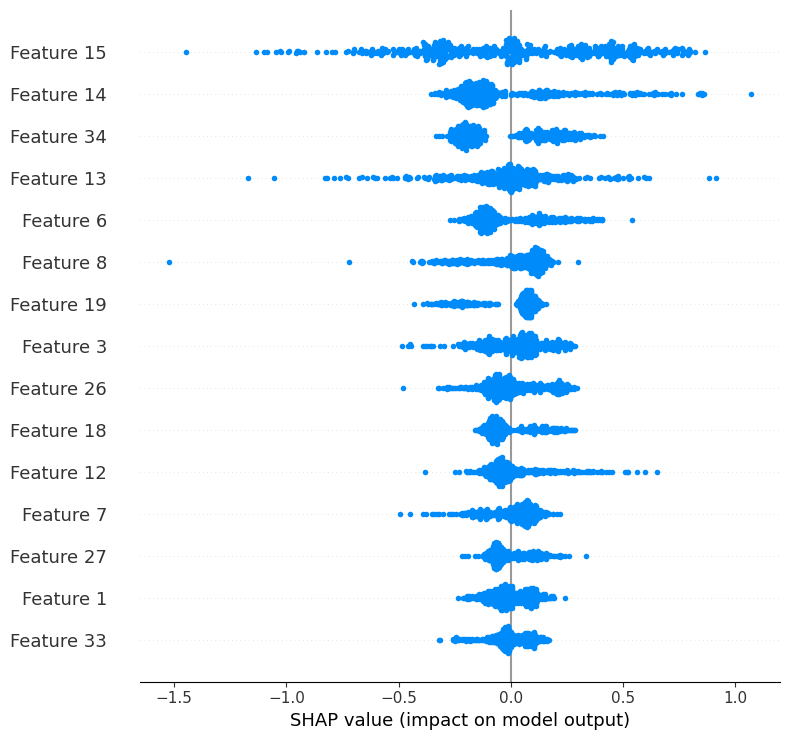

In [16]:
shap.summary_plot(shap_values,show=True, max_display=15)


Text(0.55, 0.15, 'Gini = 2 × AUC − 1\n= 2 × 0.8979 − 1\n= 0.7958')

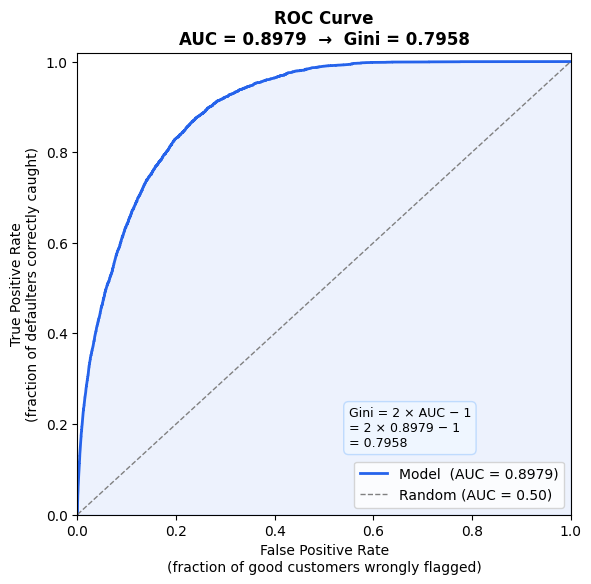

In [17]:
from sklearn.metrics import roc_curve
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(14, 6))
gs  = gridspec.GridSpec(1, 2, figure=fig)

ax1 = fig.add_subplot(gs[0])

fpr, tpr, _ = roc_curve(y_test, y_prob)
ax1.plot(fpr, tpr, color="#2563EB", linewidth=2,
         label=f"Model  (AUC = {auc:.4f})")
ax1.plot([0,1], [0,1], color="gray", linewidth=1,
         linestyle="--", label="Random (AUC = 0.50)")
ax1.fill_between(fpr, tpr, alpha=0.08, color="#2563EB")

ax1.set_xlabel("False Positive Rate\n(fraction of good customers wrongly flagged)",
               fontsize=10)
ax1.set_ylabel("True Positive Rate\n(fraction of defaulters correctly caught)",
               fontsize=10)
ax1.set_title(f"ROC Curve\nAUC = {auc:.4f}  →  Gini = {gini:.4f}",
              fontsize=12, fontweight="bold")
ax1.legend(fontsize=10)
ax1.set_xlim([0, 1])
ax1.set_ylim([0, 1.02])
ax1.annotate(f"Gini = 2 × AUC − 1\n= 2 × {auc:.4f} − 1\n= {gini:.4f}",
             xy=(0.55, 0.15), fontsize=9,
             bbox=dict(boxstyle="round,pad=0.4", facecolor="#EFF6FF",
                       edgecolor="#BFDBFE"))

In [18]:
%matplotlib inline
import matplotlib.pyplot as plt
#CAP curve 
ax2 = fig.add_subplot(gs[1])
#sorting customers based on highest risk
sorted_idx = np.argsort(y_prob)[::-1]
y_sorted = np.array(y_test)[sorted_idx]
total_bads = y_sorted.sum()
total_customers = len(y_sorted)

#cumulative percentage of defaulters caught 
cumul_bads = np.cumsum(y_sorted)/total_bads
cumul_customers = np.arange(1, total_customers + 1)/total_customers

#perfect model 
perfect_x = [0, total_bads/total_customers,1]
perfect_y = [0,1,1]

ax2.plot(cumul_customers,cumul_bads,color="#16A34A", linewidth=2,
         label=f"Model  (Gini = {gini:.4f})")
ax2.plot([0,1],[0,1],color="gray", linewidth=1, linestyle="--",
         label="Random (Gini = 0.00)")
ax2.plot(perfect_x, perfect_y,
         color="#DC2626", linewidth=1.5, linestyle=":",
         label="Perfect (Gini = 1.00)")
ax2.fill_between(cumul_customers, cumul_bads, cumul_customers,
                 alpha=0.08, color="#16A34A",
                 label="Gini area")

#defaulters caught in top 20% of customers
idx_20 = int(0.20 * total_customers)
pct_caught = cumul_bads[idx_20]*100
ax2.axvline(0.20, color="mediumpurple", linewidth=1, linestyle="--",alpha=0.7)
ax2.axhline(cumul_bads[idx_20],color="mediumpurple",linewidth=1,linestyle ="--",alpha=0.7)
ax2.annotate(f"Top 20% of customers\n {pct_caught:.0f}% of defaulters caught",xy=(0.20, cumul_bads[idx_20]),
             xytext=(0.35, cumul_bads[idx_20] - 0.12),
             fontsize=9, color="#4338CA",
             arrowprops=dict(arrowstyle="->",color="#4338CA"),
             bbox = dict(boxstyle="round,pad=0.3", facecolor="#EEF2FF",
                       edgecolor="#A5B4FC"))

ax2.set_xlabel("Fraction of customers reviewed\n(ranked by model score, highest risk first)",
               fontsize=10)
ax2.set_ylabel("Fraction of defaulters caught", fontsize=10)
ax2.set_title(f"Lorenz / CAP Curve\nGini = {gini:.4f}  ←  2 × {auc:.4f} − 1",
              fontsize=12, fontweight="bold")
ax2.legend(fontsize=9, loc="lower right")
ax2.set_xlim([0, 1])
ax2.set_ylim([0, 1.02])

plt.suptitle("Model Discrimination — ROC & Lorenz Curves",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("monitoring/roc_lorenz_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"\nAUC:  {auc:.4f}")
print(f"Gini: {gini:.4f}")
print(f"\nTop 20% of customers (ranked by model) capture {pct_caught:.0f}% of all defaulters")

<Figure size 640x480 with 0 Axes>


AUC:  0.8979
Gini: 0.7958

Top 20% of customers (ranked by model) capture 76% of all defaulters


In [19]:
import joblib
model        = joblib.load("/Users/nameerakhan/Desktop/Miscellaneous/bnpl-credit-pred/model/lgbm_calibrated.pkl")
feature_cols = joblib.load("/Users/nameerakhan/Desktop/Miscellaneous/bnpl-credit-pred/model/feature_cols.pkl")

In [22]:
# Get feature importances from the base estimator

importances = pd.Series(
    model.calibrated_classifiers_[0].estimator.feature_importances_,
    index=feature_cols
).sort_values(ascending=False)

importance_pct = (importances/importances.sum()*100).round(2)
print("Top 10 most important features:")
print(importance_pct.head(10))

Top 10 most important features:
EXT_SOURCE_3              6.88
EXT_SOURCE_2              6.61
age_years                 6.36
ext_source_mean           6.22
years_employed            5.30
EXT_SOURCE_1              4.89
AMT_ANNUITY               4.66
install_avg_delay_days    4.56
install_count             4.45
credit_income_ratio       4.15
dtype: float64
